In [1]:
import utils
import keras
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

2026-03-06 13:40:03.106140: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-06 13:40:04.465173: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-06 13:40:17.676409: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
other = 'Other car'

In [3]:
columns = ("gate1", "gate2", "lighting")
(train_x, train_y), (val_x, val_y), (test_x, test_y) = utils.read_stratified_data(columns=columns)
xs = [train_x, val_x, test_x]
ys = [train_y, val_y, test_y]

/mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett/20260303_182354203_iOS.jpg
/mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett/black-tesla-model-x-carbon-fiber-spoiler-mx22-forged-aftermarket-wheel_tCrLNla.jpg
/mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett/275815406_Andrew-Crowley-1_trans_NvBQzQNjv4BqJgZjG4XE8BZGTSy9SLp5TPzOL_bEerq8T.jpg
/mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett/Edmu_EmY1CYe.-2020-Tesla-Model-Ywire-38540856-1611748943-973_634x3962-1280x720.jpg
/mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett/kisspng-2018-tesla-model-s-tesla-motors-car-ele_fLj30kA.2230115115224762368998.png
/mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett/20260303_182059663_iOS.jpg


In [4]:
print(train_x.shape)
print(train_y.shape)
print(val_x.shape)
print(val_y.shape)
print(test_x.shape)
print(test_y.shape)

(3767, 300, 300, 3)
(3767, 6)
(806, 300, 300, 3)
(806, 6)
(807, 300, 300, 3)
(807, 6)


In [5]:
internal = pd.read_csv(utils.BASE_DIR / 'annotations/internal.csv')
external = pd.read_csv(utils.BASE_DIR / 'annotations/external.csv')

internal['year'] = internal[['year_3', 'year_s', 'year_x', 'year_y']].bfill(
    axis='columns').iloc[:, 0]
external['year'] = external[['year_3', 'year_s', 'year_x', 'year_y']].bfill(
    axis='columns').iloc[:, 0]
internal.drop(['year_3', 'year_s', 'year_x', 'year_y'], axis=1, inplace=True)
external.drop(['year_3', 'year_s', 'year_x', 'year_y'], axis=1, inplace=True)


# 1. Konkatener internal og external til ett datasett
df_all = pd.concat([internal, external], ignore_index=True)

# 2. Definer kolonner og ønsket rekkefølge
columns = ['model', 'year']
desired_order = ['Light', 'Medium', 'Dark']

# 3. Opprett nøkkelen (Model-Year)
# Vi fjerner eventuelle ekstra bindestreker hvis 'year' er tom
key = df_all[columns].fillna('').astype(str).agg(lambda x: '-'.join(filter(None, x)), axis=1)

# 4. Lag krysstabellen (Crosstab)
comparison = pd.crosstab(key, df_all['lighting'])

# 5. Sørg for at alle lysforhold-kolonner er med og i riktig rekkefølge
for col in desired_order:
    if col not in comparison.columns:
        comparison[col] = 0

comparison = comparison[desired_order].copy()

# 6. Legg til summer (Rader og Kolonner)
comparison['Total_Modell'] = comparison.sum(axis=1)
comparison.loc['TOTAL_SUM'] = comparison.sum()

# 7. Gi indeksen et navn for Excel-overskriften
comparison.index.name = 'Bilmodell-År'

# 8. Print i Excel-vennlig format (Semikolon-separert)
print(comparison.to_csv(sep='\t'))

Bilmodell-År	Light	Medium	Dark	Total_Modell
3-2017–2023	142	99	103	344
3-2024–nå	89	78	79	246
Other car	1876	622	603	3101
S-2012–2015	88	11	9	108
S-2016–2020	49	17	15	81
S-2021–nå	54	0	0	54
X-2016–2020	140	24	37	201
X-2021–nå	60	1	6	67
Y-2020–2024	391	233	234	858
Y-2025-nå	66	137	123	326
TOTAL_SUM	2955	1222	1209	5386



In [6]:
# import pandas as pd

# # 1. Definer inndata
# columns = ['model', 'lighting']
# datasets = {'Train': train_y, 'Val': val_y, 'Test': test_y}
# desired_order = ['Light', 'Medium', 'Dark']

# processed_dfs = []

# for name, df in datasets.items():
#     key = df[columns].fillna('').astype(str).agg('-'.join, axis=1)
#     ct = pd.crosstab(key, df['lighting'])
    
#     # Sørg for at alle kolonner eksisterer
#     for col in desired_order:
#         if col not in ct.columns:
#             ct[col] = 0
            
#     processed_dfs.append(ct[desired_order])

# # 2. Kombiner og summer alle datasett
# comparison = pd.concat(processed_dfs).groupby(level=0).sum()

# # 3. Legg til horisontal sum (Total per rad/modell)
# comparison['Total_Row'] = comparison.sum(axis=1)

# # 4. Legg til vertikal sum (Total per kolonne/lystype)
# # Vi bruker .loc['Total_Col'] for å opprette en ny rad nederst
# comparison.loc['TOTAL_SUM'] = comparison.sum()

# # Print i et format som kan limes rett inn i Excel
# # Kopier det som kommer ut av denne:
# comparison.to_excel("modell_fordeling.xlsx")
# print("Filen er lagret! Du finner den i samme mappe som scriptet.")

In [7]:
i = 0

gate1               1
gate2             NaN
color               3
lighting       Medium
source       internal
model       Other car
Name: 0, dtype: object


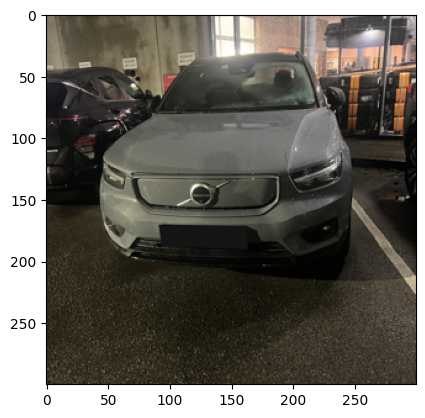

In [8]:
print(train_y.iloc[i])
plt.imshow(train_x[i])
plt.show()
i += 1

In [9]:
train_y_new = train_y["model"]
val_y_new = val_y["model"]
test_y_new = test_y["model"]
def t(x):
    if x == 'Other car':
        return 1
    return 0

vt = np.vectorize(t)

train_y_new = vt(train_y_new)
val_y_new = vt(val_y_new)
test_y_new = vt(test_y_new)

def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu")(inputs)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dropout(0.4)(x)
    outputs = keras.layers.Dense(num_classes, activation="sigmoid")(x)
    return keras.Model(inputs, outputs) 

functional_model = make_model(train_x[0].shape, 1)

epochs = 5

functional_model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

functional_model.fit(
    train_x,
    train_y_new,
    epochs=epochs,
    validation_data=(val_x, val_y_new)
)

I0000 00:00:1772800889.643308    3951 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9569 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/5


2026-03-06 13:41:40.044631: I external/local_xla/xla/service/service.cc:163] XLA service 0x785b600063d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-06 13:41:40.044902: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2026-03-06 13:41:40.210376: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-06 13:41:40.707793: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


  5/118 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4861 - loss: 0.7839

I0000 00:00:1772800907.925842    4546 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 88ms/step - accuracy: 0.6913 - loss: 0.5893 - val_accuracy: 0.7345 - val_loss: 0.5434
Epoch 2/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7895 - loss: 0.4678 - val_accuracy: 0.7568 - val_loss: 0.5060
Epoch 3/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8346 - loss: 0.3933 - val_accuracy: 0.7667 - val_loss: 0.5036
Epoch 4/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8882 - loss: 0.3032 - val_accuracy: 0.7395 - val_loss: 0.5238
Epoch 5/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9217 - loss: 0.2350 - val_accuracy: 0.7556 - val_loss: 0.5268


In [10]:
functional_model.evaluate(test_x, test_y_new)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7732 - loss: 0.5178


[0.5177944302558899, 0.7732341885566711]

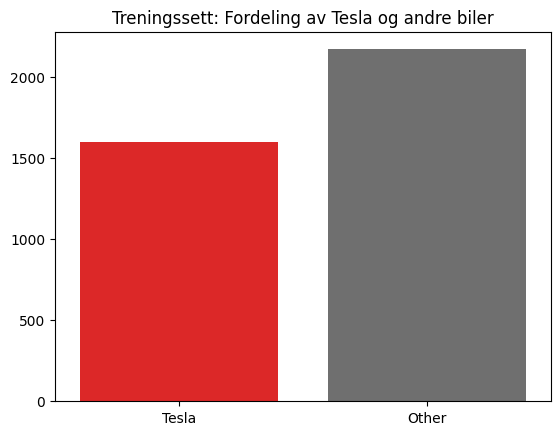

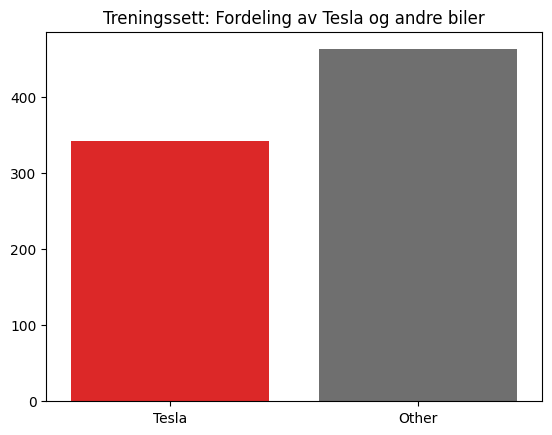

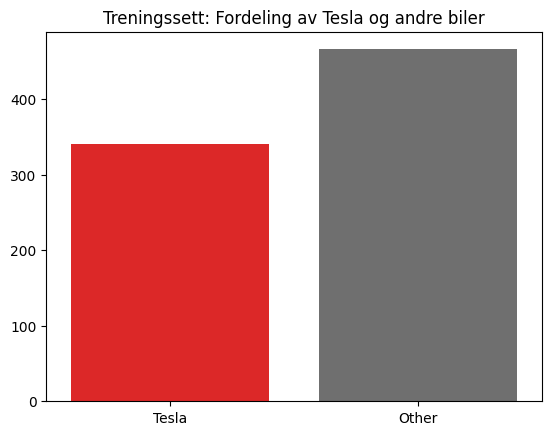

In [11]:
for df in ys:
    other = 'Other car'

    names = ['Tesla', 'Other']
    counts = [len(df[df['model'] != other]), len(df[df['model'] == other])]

    plot = sns.barplot(x=names, y=counts, hue=names, palette=["#fa0a0a", "#6f6f6f"], legend=False)
    plot.set_title(f'Treningssett: Fordeling av Tesla og andre biler')
    plt.show()  



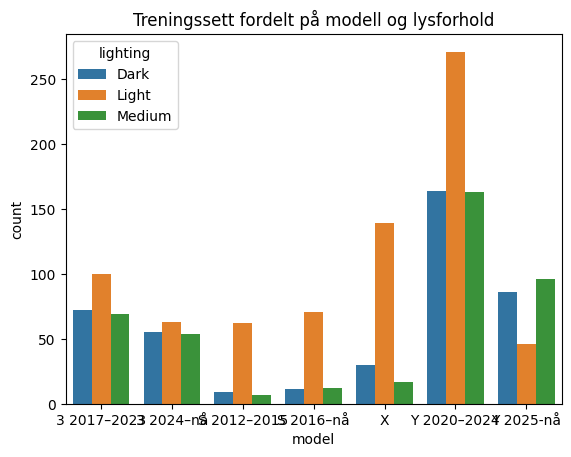

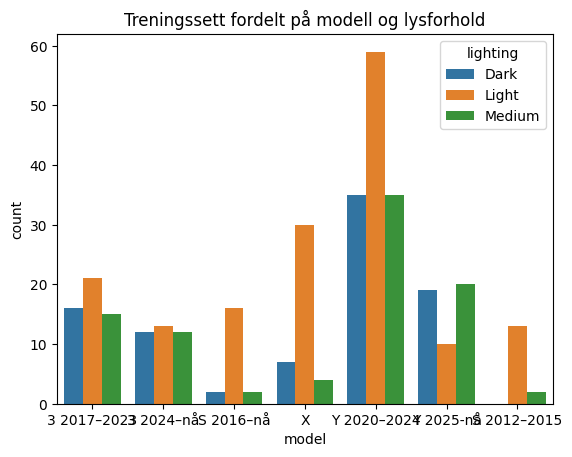

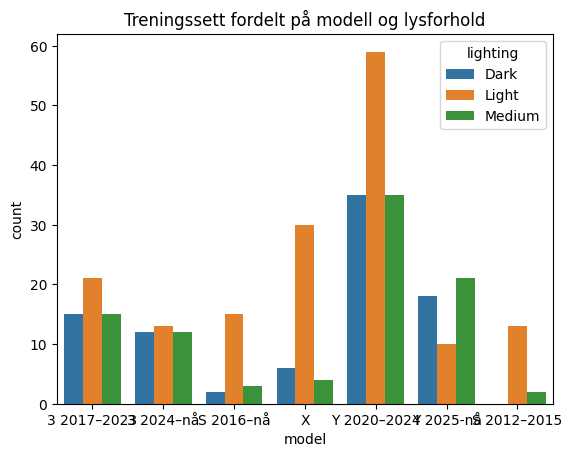

In [12]:
for df in ys:
    other = 'Other car'
    tesla = df[df['model'] != other].sort_values(by="model").sort_values(by="lighting", kind='stable')

    sns.countplot(data=tesla, x="model", hue="lighting").set_title("Treningssett fordelt på modell og lysforhold")
    plt.show()



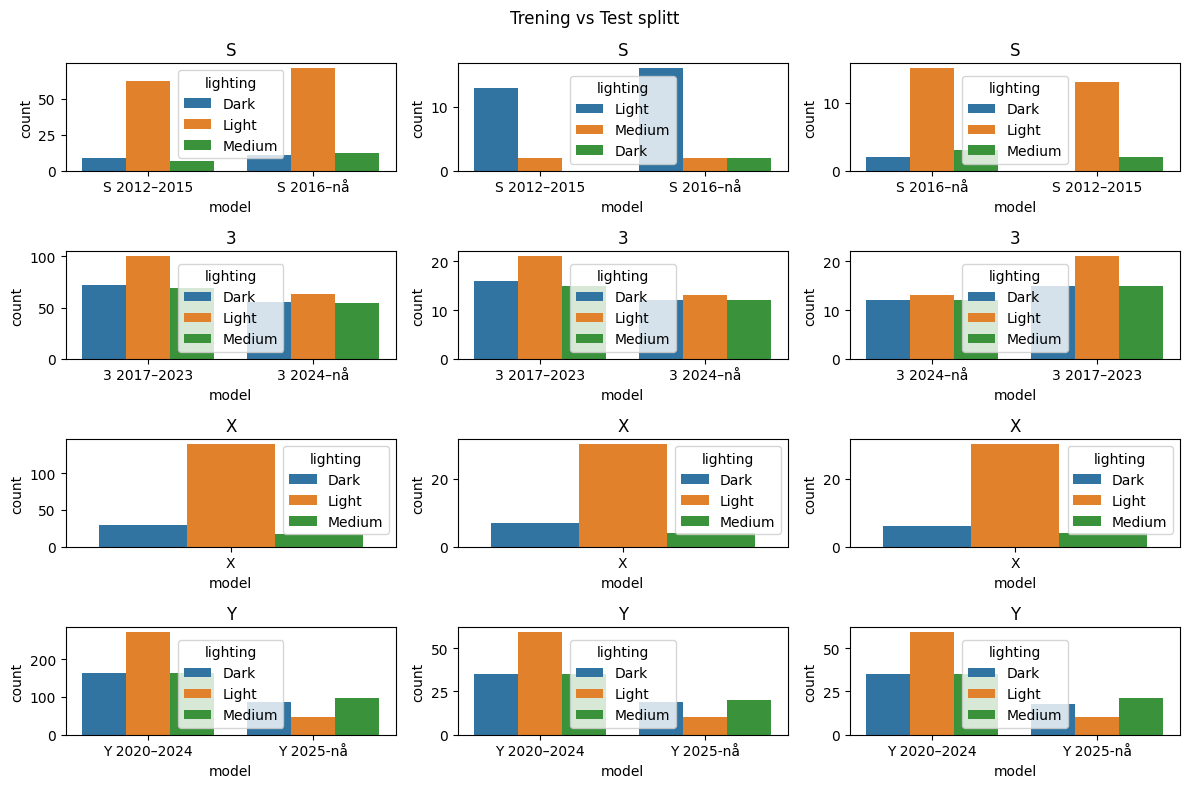

In [13]:
train_y_split = [
    train_y[train_y['model'].str.contains('S')].sort_values('lighting').sort_values('model', kind='stable'),
    train_y[train_y['model'].str.contains('3')].sort_values('lighting').sort_values('model', kind='stable'),
    train_y[train_y['model'].str.contains('X')].sort_values('lighting').sort_values('model', kind='stable'),
    train_y[train_y['model'].str.contains('Y')].sort_values('lighting').sort_values('model', kind='stable')
]

val_y_split =[
    val_y[val_y['model'].str.contains('S')].sort_values('lighting').sort_values('model', kind='stable'),
    val_y[val_y['model'].str.contains('3')].sort_values('lighting').sort_values('model', kind='stable'),
    val_y[val_y['model'].str.contains('X')].sort_values('lighting').sort_values('model', kind='stable'),
    val_y[val_y['model'].str.contains('Y')].sort_values('lighting').sort_values('model', kind='stable')
]

test_y_split = [
    test_y[test_y['model'].str.contains('S')].sort_values('lighting').sort_values('lighting', kind='stable'),
    test_y[test_y['model'].str.contains('3')].sort_values('lighting').sort_values('lighting', kind='stable'),
    test_y[test_y['model'].str.contains('X')].sort_values('lighting').sort_values('lighting', kind='stable'),
    test_y[test_y['model'].str.contains('Y')].sort_values('lighting').sort_values('lighting', kind='stable')
]

models = ["S", "3", "X", "Y"]
fig, axes = plt.subplots(4, 3, figsize=(12, 8))
fig.suptitle(f'Trening vs Test splitt')
for i in range(0,2):
    for j in range(0,2):
        sns.countplot(x='model', data=train_y_split[i*2 + j], ax=axes[i*2+j,0], hue='lighting')
        axes[i*2+j,0].title.set_text(models[i*2 + j])
        sns.countplot(x='model', data=val_y_split[i*2 + j], ax=axes[i*2+j,1], hue='lighting')
        axes[i*2+j,1].title.set_text(models[i*2 + j])
        sns.countplot(x='model', data=test_y_split[i*2 + j], ax=axes[i*2+j,2], hue='lighting')
        axes[i*2+j,2].title.set_text(models[i*2 + j])

plt.tight_layout()
plt.show()

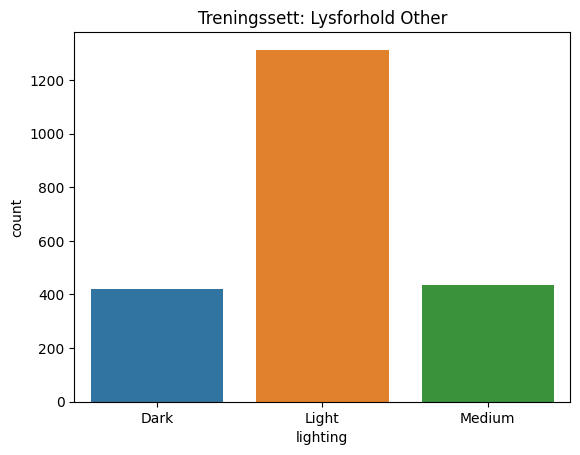

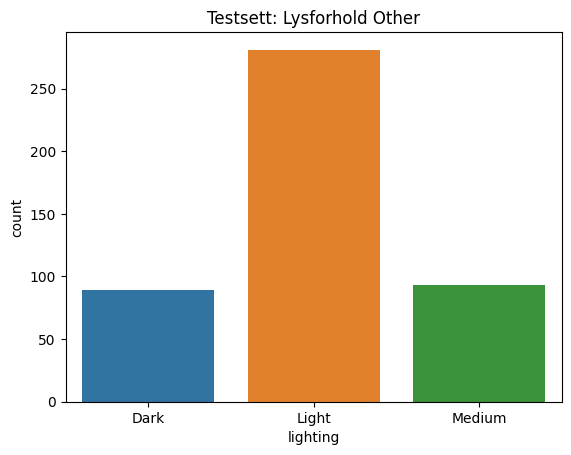

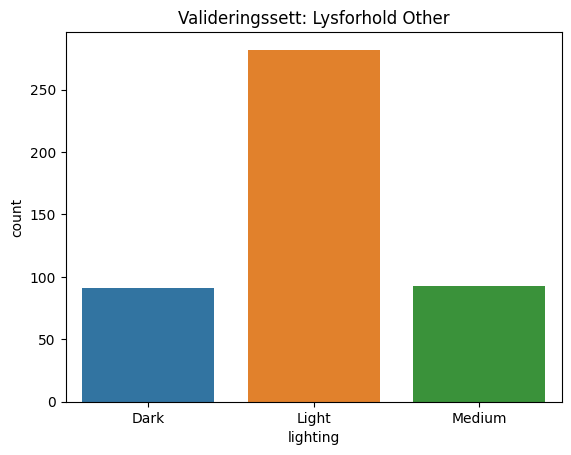

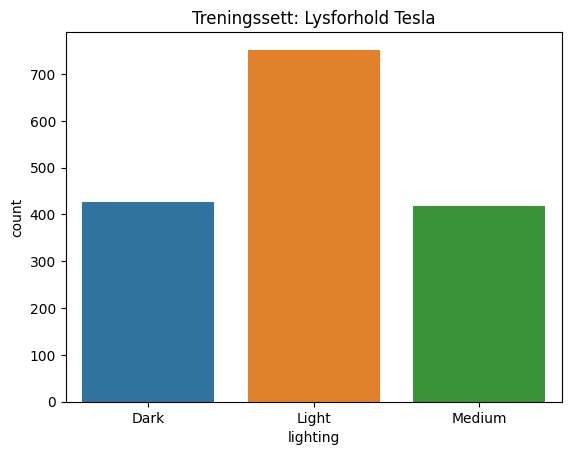

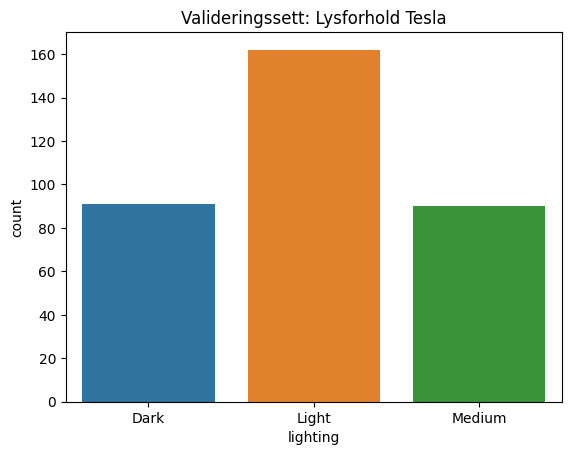

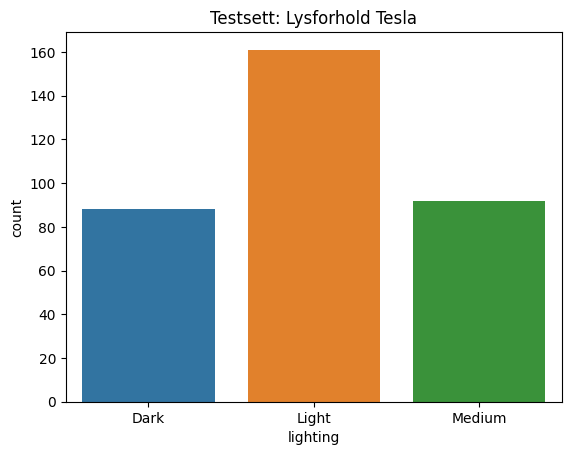

In [14]:
df = train_y[train_y["model"] == other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Treningssett: Lysforhold Other')
plt.show()

df = val_y[val_y["model"] == other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Testsett: Lysforhold Other')
plt.show()

df = test_y[test_y["model"] == other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Valideringssett: Lysforhold Other')
plt.show()

df = train_y[train_y["model"] != other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Treningssett: Lysforhold Tesla')
plt.show()

df = val_y[val_y["model"] != other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Valideringssett: Lysforhold Tesla')
plt.show()

df = test_y[test_y["model"] != other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Testsett: Lysforhold Tesla')
plt.show()

